# Name - Swatej Sonawane
# Github Username - swatejsonawane18
# USC ID - 9314761761

References :

https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RidgeCV.html
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html
https://stackoverflow.com/questions/60216879/what-does-sklearn-linear-model-ridgecv-normalize-parameter-exactly-do
https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html
https://stackoverflow.com/questions/69429691/gridsearchcv-not-choosing-the-best-hyperparameters-for-xgboost

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn
from sklearn import tree
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import graphviz
import csv
from sklearn.linear_model import LinearRegression, RidgeCV, Ridge, LassoCV,Lasso
import math
from xgboost import XGBRegressor
import warnings

# Q1 a

In [2]:
df1 = pd.read_csv('../data/diagnosis.data',encoding='utf-16', header=None,sep='\t')

# Data Description - 

a1 Temperature of patient { 35C-42C }<br>
a2 Occurrence of nausea { yes, no }<br>
a3 Lumbar pain { yes, no }<br>
a4 Urine pushing (continuous need for urination) { yes, no }<br>
a5 Micturition pains { yes, no }<br>
a6 Burning of urethra, itch, swelling of urethra outlet { yes, no }<br>
d1 decision: Inflammation of urinary bladder { yes, no }<br>
d2 decision: Nephritis of renal pelvis origin { yes, no }<br>

In [3]:
headers = ['Temperature', 'Nausea', 'Lumbar', 'Urine', 'Micturition', 'Urethra',
       'Bladder', 'Pelvis']

In [4]:
df1.columns= headers

In [5]:
df1

,Temperature,Nausea,Lumbar,Urine,Micturition,Urethra,Bladder,Pelvis
0,"35,5",no,yes,no,no,no,no,no
1,"35,9",no,no,yes,yes,yes,yes,no
2,"35,9",no,yes,no,no,no,no,no
3,"36,0",no,no,yes,yes,yes,yes,no
4,"36,0",no,yes,no,no,no,no,no
...,...,...,...,...,...,...,...,...
115,"41,4",no,yes,yes,no,yes,no,yes
116,"41,5",no,no,no,no,no,no,no
117,"41,5",yes,yes,no,yes,no,no,yes
118,"41,5",no,yes,yes,no,yes,no,yes


In [6]:
df1['Temperature']=df1['Temperature'].replace(',', '.', regex=True)

In [7]:
df1=df1.replace(to_replace=['no', 'yes'], value=[0, 1])

In [8]:
df1

,Temperature,Nausea,Lumbar,Urine,Micturition,Urethra,Bladder,Pelvis
0,35.5,0,1,0,0,0,0,0
1,35.9,0,0,1,1,1,1,0
2,35.9,0,1,0,0,0,0,0
3,36.0,0,0,1,1,1,1,0
4,36.0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...
115,41.4,0,1,1,0,1,0,1
116,41.5,0,0,0,0,0,0,0
117,41.5,1,1,0,1,0,0,1
118,41.5,0,1,1,0,1,0,1


In [9]:
df1['Temperature'] = df1['Temperature'].astype(float)
df1['Nausea'] = df1['Nausea'].astype(int)
df1['Lumbar'] = df1['Lumbar'].astype(int)
df1['Urine'] = df1['Urine'].astype(int)
df1['Micturition'] = df1['Micturition'].astype(int)
df1['Urethra'] = df1['Urethra'].astype(int)
df1['Bladder'] = df1['Bladder'].astype(int)
df1['Pelvis'] = df1['Pelvis'].astype(int)

In [10]:
x,y = df1.iloc[:,:6],df1.iloc[:,6:]

# Q1 b

In [11]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=0)

In [12]:
predictors = ['Temperature', 'Nausea', 'Lumbar', 'Urine', 'Micturition', 'Urethra']
classes = ['Bladder', 'Pelvis']

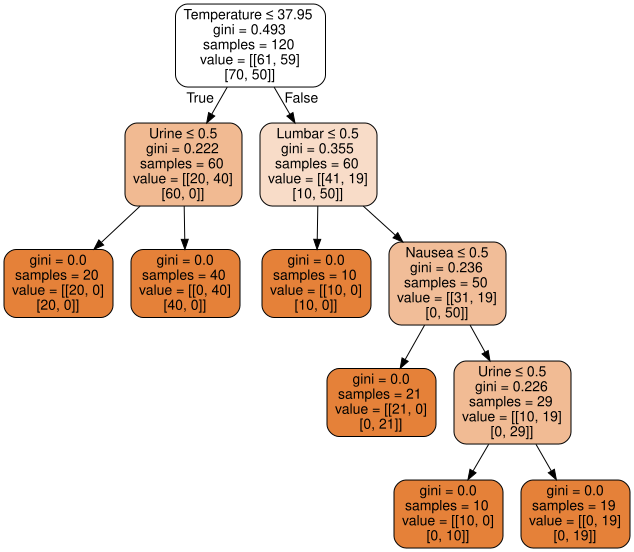

In [13]:
dt_clf = tree.DecisionTreeClassifier()
dt_clf.fit(x,y)
dot_data = tree.export_graphviz(dt_clf, out_file=None,feature_names=predictors,class_names=classes, filled=True, rounded=True,special_characters=True)  
dt_graph = graphviz.Source(dot_data)  
dt_graph 

# Q1 c

In [14]:
rules = tree.export_text(dt_clf)
print(rules)

|--- feature_0 <= 37.95
|   |--- feature_3 <= 0.50
|   |   |--- class: 0
|   |--- feature_3 >  0.50
|   |   |--- class: 1
|--- feature_0 >  37.95
|   |--- feature_2 <= 0.50
|   |   |--- class: 0
|   |--- feature_2 >  0.50
|   |   |--- feature_1 <= 0.50
|   |   |   |--- class: 0
|   |   |--- feature_1 >  0.50
|   |   |   |--- feature_3 <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- feature_3 >  0.50
|   |   |   |   |--- class: 0



# Q1 d

alpha:0.0	score:1.0	no_of_nodes: 11	depth: 4

alpha:0.04908333333333333	score:1.0	no_of_nodes: 11	depth: 4

alpha:0.07947222222222226	score:0.7444444444444445	no_of_nodes: 5	depth: 2

alpha:0.1111111111111111	score:0.7444444444444445	no_of_nodes: 5	depth: 2

alpha:0.204236111111111	score:0.25555555555555554	no_of_nodes: 1	depth: 0



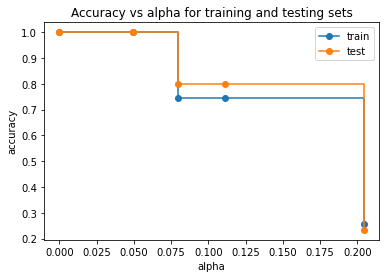

In [15]:
path = dt_clf.cost_complexity_pruning_path(x,y)
ccp_alphas, impurities = path.ccp_alphas, path.impurities
# As alpha increases, more of the tree is pruned, 
# which increases the total impurity of its leaves and decreases the depth of the tree
clfs = []
node_counts=[]
depth=[]
train_scores=[]
test_scores=[]

for ccp_alpha in ccp_alphas:
    dt_clf = tree.DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
    dt_clf.fit(x_train,y_train)
    clfs.append(dt_clf)
    node_counts.append(dt_clf.tree_.node_count)
    depth.append(dt_clf.tree_.max_depth)
    train_scores.append(dt_clf.score(x_train, y_train))
    test_scores.append(dt_clf.score(x_test, y_test))
    print(f'alpha:{ccp_alpha}\tscore:{dt_clf.score(x_train,y_train)}\tno_of_nodes: {dt_clf.tree_.node_count}\tdepth: {dt_clf.tree_.max_depth}\n')


fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

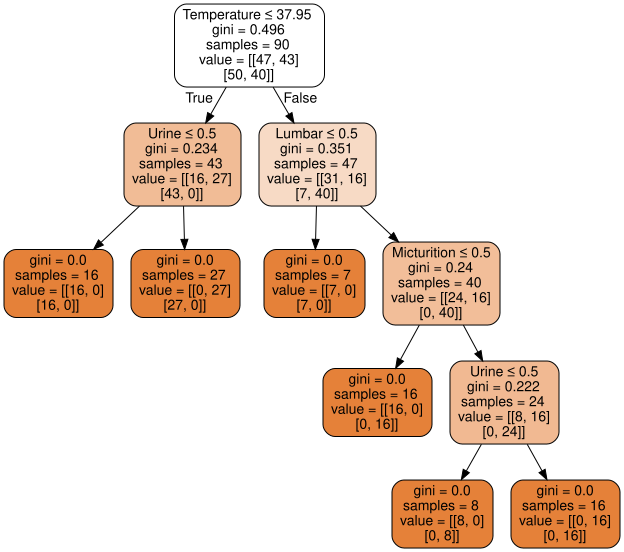

In [16]:
best_alpha = ccp_alphas[1]
best_clf = tree.DecisionTreeClassifier(random_state=0,ccp_alpha=best_alpha)
best_clf.fit(x_train,y_train)
dot_data = tree.export_graphviz(best_clf, out_file=None,feature_names=predictors,class_names=classes, filled=True, rounded=True,special_characters=True)  
pruned_dt_graph = graphviz.Source(dot_data)  
pruned_dt_graph

In [17]:
rules_pruned = tree.export_text(best_clf)
print(rules_pruned)

|--- feature_0 <= 37.95
|   |--- feature_3 <= 0.50
|   |   |--- class: 0
|   |--- feature_3 >  0.50
|   |   |--- class: 1
|--- feature_0 >  37.95
|   |--- feature_2 <= 0.50
|   |   |--- class: 0
|   |--- feature_2 >  0.50
|   |   |--- feature_4 <= 0.50
|   |   |   |--- class: 0
|   |   |--- feature_4 >  0.50
|   |   |   |--- feature_3 <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- feature_3 >  0.50
|   |   |   |   |--- class: 0



# Q2 a

In [18]:
attributes =["state","county","community","communityname","fold","population","householdsize","racepctblack","racePctWhite",
"racePctAsian","racePctHisp","agePct12t21","agePct12t29","agePct16t24","agePct65up","numbUrban","pctUrban","medIncome",
"pctWWage","pctWFarmSelf","pctWInvInc","pctWSocSec","pctWPubAsst","pctWRetire","medFamInc","perCapInc","whitePerCap",
"blackPerCap","indianPerCap","AsianPerCap","OtherPerCap","HispPerCap","NumUnderPov","PctPopUnderPov","PctLess9thGrade",
"PctNotHSGrad","PctBSorMore","PctUnemployed","PctEmploy","PctEmplManu","PctEmplProfServ","PctOccupManu","PctOccupMgmtProf",
"MalePctDivorce","MalePctNevMarr","FemalePctDiv","TotalPctDiv","PersPerFam","PctFam2Par","PctKids2Par","PctYoungKids2Par",
"PctTeen2Par","PctWorkMomYoungKids","PctWorkMom","NumIlleg","PctIlleg","NumImmig","PctImmigRecent","PctImmigRec5",
"PctImmigRec8","PctImmigRec10","PctRecentImmig","PctRecImmig5","PctRecImmig8","PctRecImmig10","PctSpeakEnglOnly",
"PctNotSpeakEnglWell","PctLargHouseFam","PctLargHouseOccup","PersPerOccupHous","PersPerOwnOccHous","PersPerRentOccHous",
"PctPersOwnOccup","PctPersDenseHous","PctHousLess3BR","MedNumBR","HousVacant","PctHousOccup","PctHousOwnOcc","PctVacantBoarded",
"PctVacMore6Mos","MedYrHousBuilt","PctHousNoPhone","PctWOFullPlumb","OwnOccLowQuart","OwnOccMedVal","OwnOccHiQuart","RentLowQ",
"RentMedian","RentHighQ","MedRent","MedRentPctHousInc","MedOwnCostPctInc","MedOwnCostPctIncNoMtg","NumInShelters","NumStreet",
"PctForeignBorn","PctBornSameState","PctSameHouse85","PctSameCity85","PctSameState85","LemasSwornFT","LemasSwFTPerPop",
"LemasSwFTFieldOps","LemasSwFTFieldPerPop","LemasTotalReq","LemasTotReqPerPop","PolicReqPerOffic","PolicPerPop",
"RacialMatchCommPol","PctPolicWhite","PctPolicBlack","PctPolicHisp","PctPolicAsian","PctPolicMinor","OfficAssgnDrugUnits",
"NumKindsDrugsSeiz","PolicAveOTWorked","LandArea","PopDens","PctUsePubTrans","PolicCars","PolicOperBudg","LemasPctPolicOnPatr",
"LemasGangUnitDeploy","LemasPctOfficDrugUn","PolicBudgPerPop","ViolentCrimesPerPop"]

non_pred_attributes = ["state", "county", "community", "communityname", "fold"]

pred_attributes = ["population","householdsize","racepctblack","racePctWhite",
"racePctAsian","racePctHisp","agePct12t21","agePct12t29","agePct16t24","agePct65up","numbUrban","pctUrban","medIncome",
"pctWWage","pctWFarmSelf","pctWInvInc","pctWSocSec","pctWPubAsst","pctWRetire","medFamInc","perCapInc","whitePerCap",
"blackPerCap","indianPerCap","AsianPerCap","OtherPerCap","HispPerCap","NumUnderPov","PctPopUnderPov","PctLess9thGrade",
"PctNotHSGrad","PctBSorMore","PctUnemployed","PctEmploy","PctEmplManu","PctEmplProfServ","PctOccupManu","PctOccupMgmtProf",
"MalePctDivorce","MalePctNevMarr","FemalePctDiv","TotalPctDiv","PersPerFam","PctFam2Par","PctKids2Par","PctYoungKids2Par",
"PctTeen2Par","PctWorkMomYoungKids","PctWorkMom","NumIlleg","PctIlleg","NumImmig","PctImmigRecent","PctImmigRec5",
"PctImmigRec8","PctImmigRec10","PctRecentImmig","PctRecImmig5","PctRecImmig8","PctRecImmig10","PctSpeakEnglOnly",
"PctNotSpeakEnglWell","PctLargHouseFam","PctLargHouseOccup","PersPerOccupHous","PersPerOwnOccHous","PersPerRentOccHous",
"PctPersOwnOccup","PctPersDenseHous","PctHousLess3BR","MedNumBR","HousVacant","PctHousOccup","PctHousOwnOcc","PctVacantBoarded",
"PctVacMore6Mos","MedYrHousBuilt","PctHousNoPhone","PctWOFullPlumb","OwnOccLowQuart","OwnOccMedVal","OwnOccHiQuart","RentLowQ",
"RentMedian","RentHighQ","MedRent","MedRentPctHousInc","MedOwnCostPctInc","MedOwnCostPctIncNoMtg","NumInShelters","NumStreet",
"PctForeignBorn","PctBornSameState","PctSameHouse85","PctSameCity85","PctSameState85","LemasSwornFT","LemasSwFTPerPop",
"LemasSwFTFieldOps","LemasSwFTFieldPerPop","LemasTotalReq","LemasTotReqPerPop","PolicReqPerOffic","PolicPerPop",
"RacialMatchCommPol","PctPolicWhite","PctPolicBlack","PctPolicHisp","PctPolicAsian","PctPolicMinor","OfficAssgnDrugUnits",
"NumKindsDrugsSeiz","PolicAveOTWorked","LandArea","PopDens","PctUsePubTrans","PolicCars","PolicOperBudg","LemasPctPolicOnPatr",
"LemasGangUnitDeploy","LemasPctOfficDrugUn","PolicBudgPerPop","ViolentCrimesPerPop"]

df2 = pd.read_csv(r"../data/communities.data", header= None, names = attributes)

df2_pred = df2[pred_attributes]
print(df2_pred)

      population  householdsize  racepctblack  racePctWhite  racePctAsian  \
0           0.19           0.33          0.02          0.90          0.12   
1           0.00           0.16          0.12          0.74          0.45   
2           0.00           0.42          0.49          0.56          0.17   
3           0.04           0.77          1.00          0.08          0.12   
4           0.01           0.55          0.02          0.95          0.09   
...          ...            ...           ...           ...           ...   
1989        0.01           0.40          0.10          0.87          0.12   
1990        0.05           0.96          0.46          0.28          0.83   
1991        0.16           0.37          0.25          0.69          0.04   
1992        0.08           0.51          0.06          0.87          0.22   
1993        0.20           0.78          0.14          0.46          0.24   

      racePctHisp  agePct12t21  agePct12t29  agePct16t24  agePct65up  ...  

In [19]:
df2_pred.dtypes

population             float64
householdsize          float64
racepctblack           float64
racePctWhite           float64
racePctAsian           float64
                        ...   
LemasPctPolicOnPatr     object
LemasGangUnitDeploy     object
LemasPctOfficDrugUn    float64
PolicBudgPerPop         object
ViolentCrimesPerPop    float64
Length: 123, dtype: object

# Q2 b

In [20]:
df2_pred = df2_pred.apply(pd.to_numeric, errors='coerce')
print(df2_pred)

      population  householdsize  racepctblack  racePctWhite  racePctAsian  \
0           0.19           0.33          0.02          0.90          0.12   
1           0.00           0.16          0.12          0.74          0.45   
2           0.00           0.42          0.49          0.56          0.17   
3           0.04           0.77          1.00          0.08          0.12   
4           0.01           0.55          0.02          0.95          0.09   
...          ...            ...           ...           ...           ...   
1989        0.01           0.40          0.10          0.87          0.12   
1990        0.05           0.96          0.46          0.28          0.83   
1991        0.16           0.37          0.25          0.69          0.04   
1992        0.08           0.51          0.06          0.87          0.22   
1993        0.20           0.78          0.14          0.46          0.24   

      racePctHisp  agePct12t21  agePct12t29  agePct16t24  agePct65up  ...  

In [21]:
df2_pred.dtypes

population             float64
householdsize          float64
racepctblack           float64
racePctWhite           float64
racePctAsian           float64
                        ...   
LemasPctPolicOnPatr    float64
LemasGangUnitDeploy    float64
LemasPctOfficDrugUn    float64
PolicBudgPerPop        float64
ViolentCrimesPerPop    float64
Length: 123, dtype: object

In [22]:
df2_pred = df2_pred.fillna(df2_pred.mean())
print(df2_pred)

      population  householdsize  racepctblack  racePctWhite  racePctAsian  \
0           0.19           0.33          0.02          0.90          0.12   
1           0.00           0.16          0.12          0.74          0.45   
2           0.00           0.42          0.49          0.56          0.17   
3           0.04           0.77          1.00          0.08          0.12   
4           0.01           0.55          0.02          0.95          0.09   
...          ...            ...           ...           ...           ...   
1989        0.01           0.40          0.10          0.87          0.12   
1990        0.05           0.96          0.46          0.28          0.83   
1991        0.16           0.37          0.25          0.69          0.04   
1992        0.08           0.51          0.06          0.87          0.22   
1993        0.20           0.78          0.14          0.46          0.24   

      racePctHisp  agePct12t21  agePct12t29  agePct16t24  agePct65up  ...  

In [23]:
train_2 = df2_pred.iloc[:1495,:]
test_2 = df2_pred.iloc[1495:,:]
train_x_2 = df2_pred.iloc[:1495,:-1]
test_x_2 = df2_pred.iloc[1495:,:-1]
train_y_2 = df2_pred.loc[:1494,"ViolentCrimesPerPop"]
test_y_2 = df2_pred.loc[1495:,"ViolentCrimesPerPop"]

# Q2 c

<AxesSubplot:>

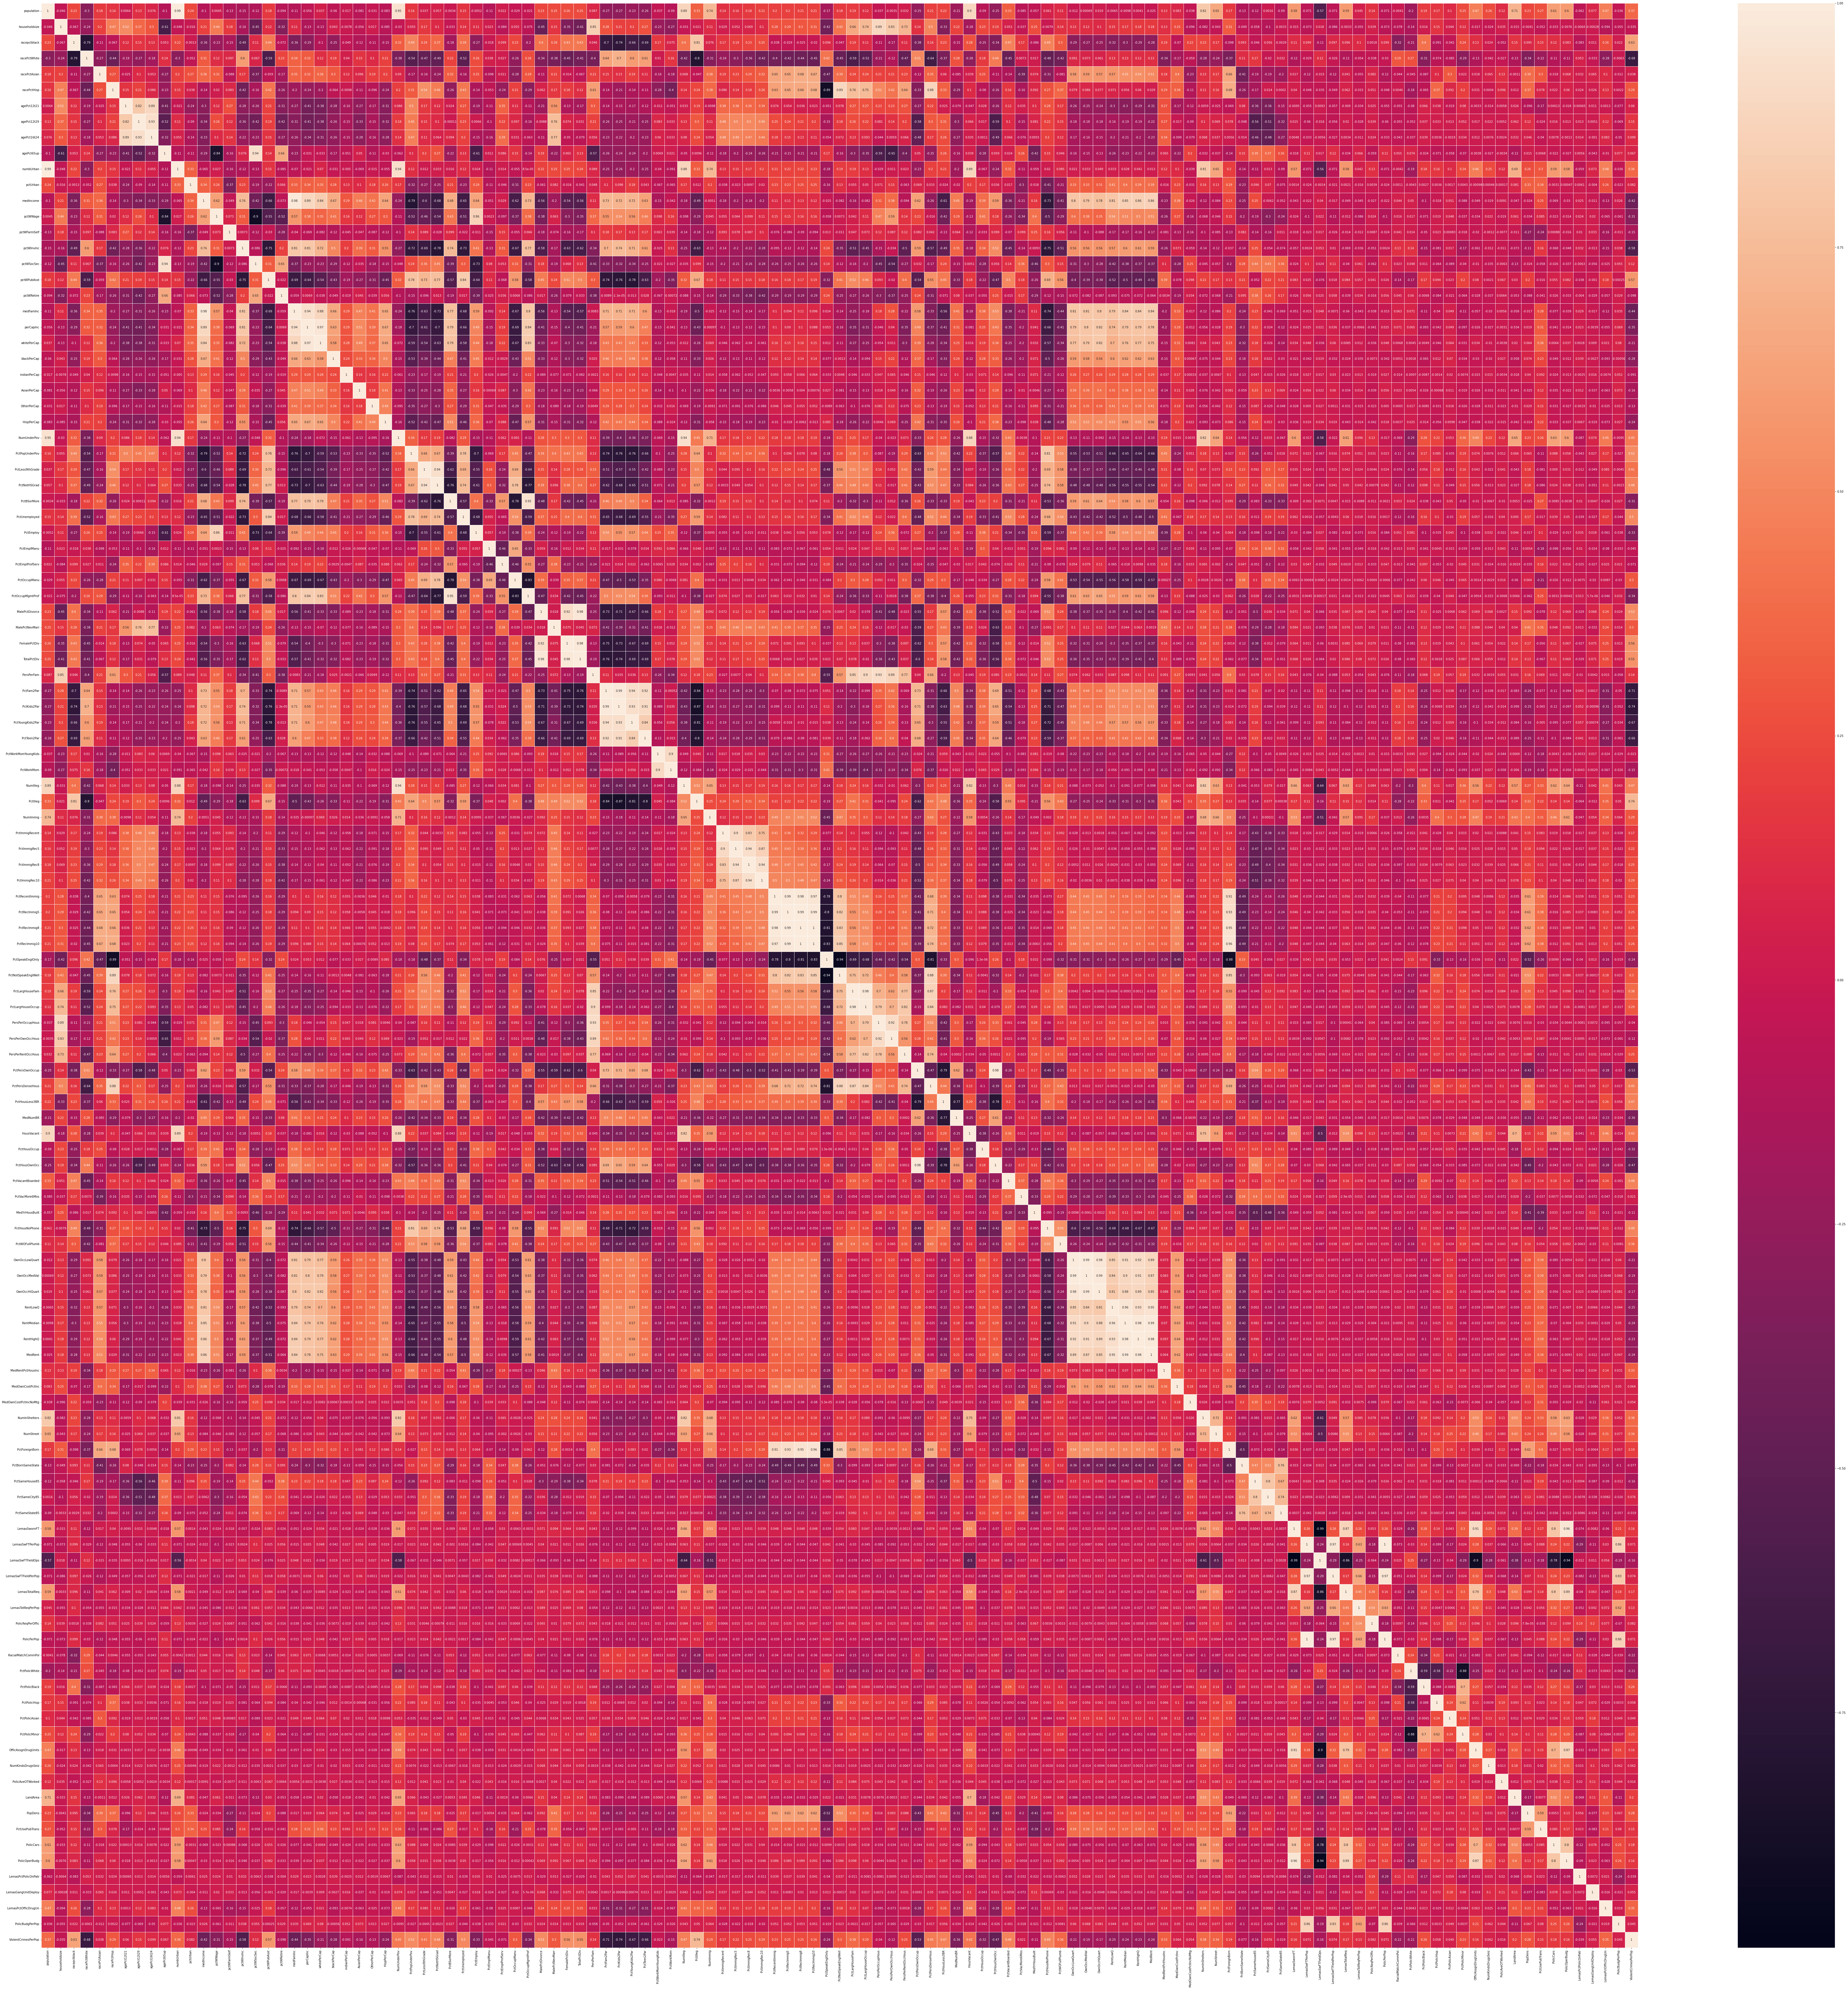

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(123,123))      
sns.heatmap(df2_pred.corr(), annot=True, linewidths=.5, ax=ax)

# Q2 d

In [25]:
coef_of_var = df2_pred.std()/df2_pred.mean()
print(coef_of_var)

population             2.203503
householdsize          0.353298
racepctblack           1.410920
racePctWhite           0.323782
racePctAsian           1.359162
                         ...   
LemasPctPolicOnPatr    0.122331
LemasGangUnitDeploy    0.368040
LemasPctOfficDrugUn    2.555266
PolicBudgPerPop        0.337281
ViolentCrimesPerPop    0.979015
Length: 123, dtype: float64


In [26]:
df_signif_attributes = pd.DataFrame(coef_of_var)
df_signif_attributes  = df_signif_attributes.reset_index()
df_signif_attributes = df_signif_attributes.rename(columns={'index':'feature',0:'CV'})

df_signif_attributes = df_signif_attributes.sort_values(by="CV",ascending=False).reset_index(drop=True)
print(df_signif_attributes)

                 feature        CV
0              NumStreet  4.407702
1          NumInShelters  3.485481
2               NumIlleg  2.994196
3               NumImmig  2.900497
4    LemasPctOfficDrugUn  2.555266
..                   ...       ...
118    NumKindsDrugsSeiz  0.145956
119   RacialMatchCommPol  0.131417
120  LemasPctPolicOnPatr  0.122331
121        PctPolicWhite  0.121659
122    LemasSwFTFieldOps  0.057126

[123 rows x 2 columns]


# Q2 e

In [27]:
n_sigif_attributes = math.floor(math.sqrt(128))
df_signif_attributes=df_signif_attributes.iloc[:n_sigif_attributes]
print(df_signif_attributes)

                feature        CV
0             NumStreet  4.407702
1         NumInShelters  3.485481
2              NumIlleg  2.994196
3              NumImmig  2.900497
4   LemasPctOfficDrugUn  2.555266
5           NumUnderPov  2.304970
6            population  2.203503
7             numbUrban  2.001744
8            HousVacant  1.958780
9              LandArea  1.678031
10          racePctHisp  1.614278


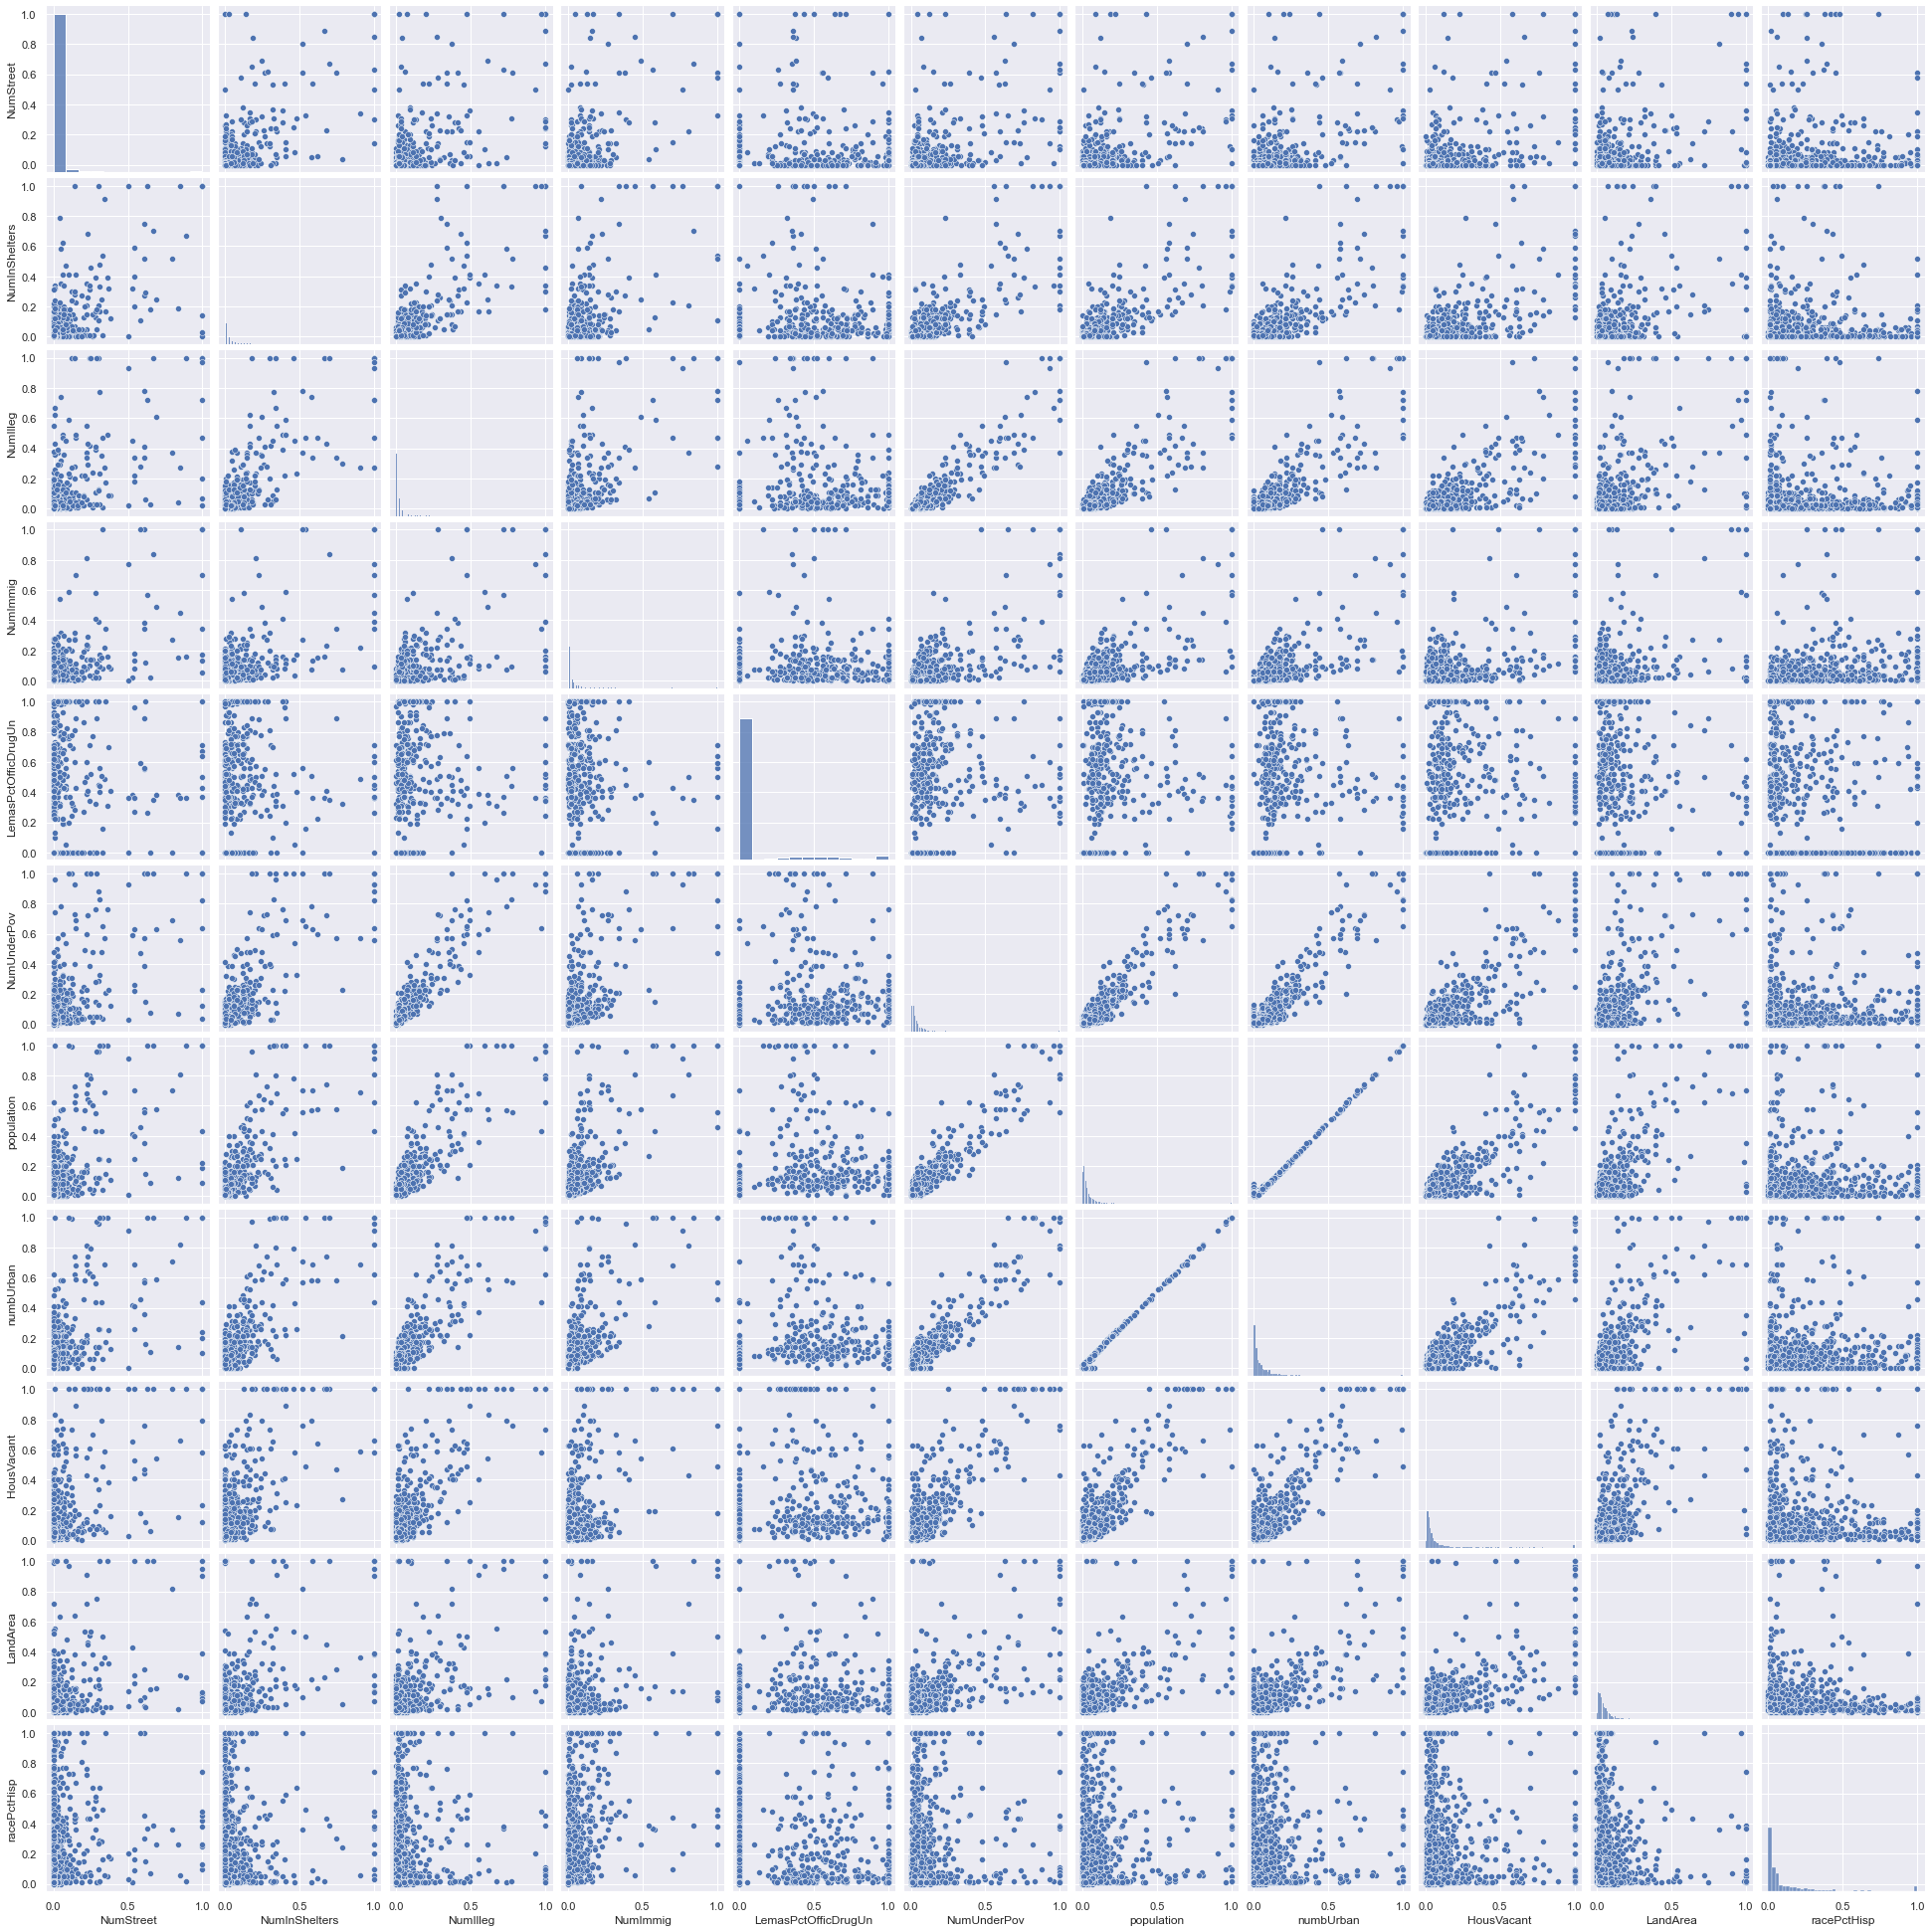

In [28]:
sns.set()
sns.pairplot(df2_pred,diag_kind='hist', vars=df_signif_attributes['feature'])

<AxesSubplot:>

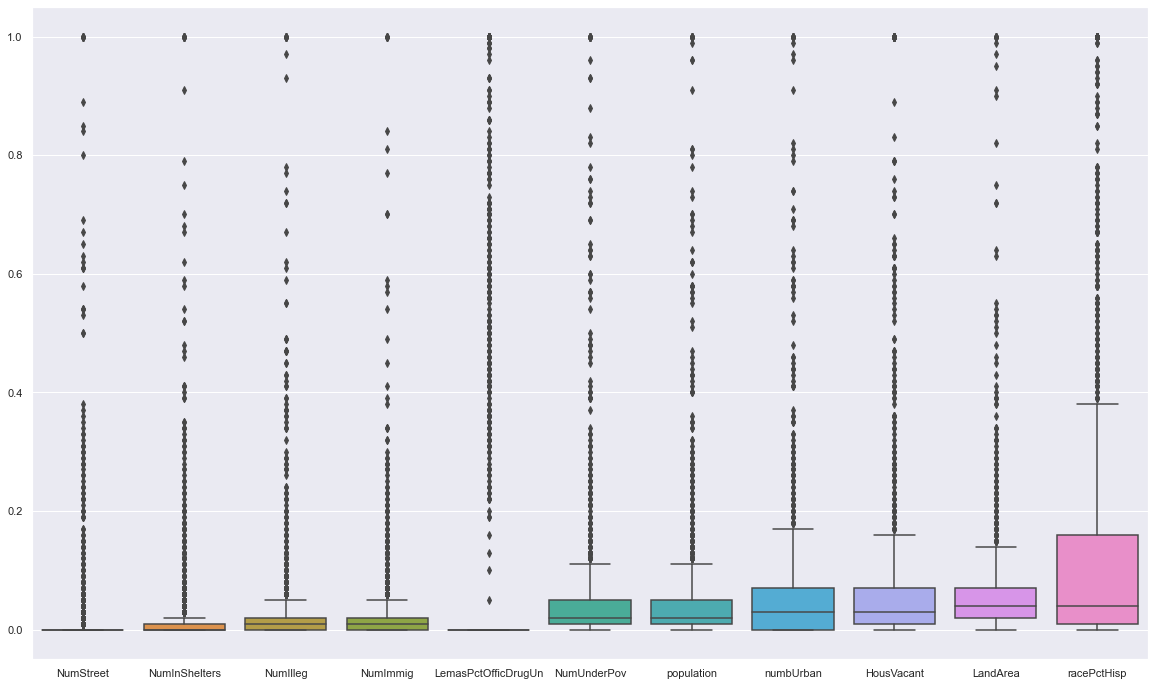

In [29]:
import matplotlib.pyplot as plt
fig = plt.gcf()

fig.set_size_inches(20, 12)
sns.boxplot(data=df2_pred[df_signif_attributes['feature']])


Conclusions:

1. There is a linear relationship between 'population' (population for community) and 'numbUrban' (number of people living in areas classified as urban). 
2. There is a linear relationship betweeen 'population' (population for community) and 'NumUnderPov' (number of people under the poverty level).
3. There is a linear relationship betweeen 'NumUnderPov' (number of people under the poverty level) and 'NumIlleg' (number of kids born to never married).
4. There is a linear relationship betweeen 'NumUnderPov' (number of people under the poverty level) and 'numbUrban' (number of people living in areas classified as urban).

Hence Positive Corelation exists.

# Q2 f 

In [30]:
lr = LinearRegression()
lr.fit(train_x_2,train_y_2)
pred_train=lr.predict(train_x_2)
pred_test = lr.predict(test_x_2)


print(f"The train error of the Linear regression model is {metrics.mean_squared_error(train_y_2,pred_train)}\n")
print(f"The test error of the Linear regression model is {metrics.mean_squared_error(test_y_2,pred_test)}\n")

The train error of the Linear regression model is 0.016269615741740653

The test error of the Linear regression model is 0.789725527436134



# Q2 g

In [31]:
a=10**np.linspace(10,-2,50)*0.5

clf = RidgeCV(alphas=a,fit_intercept=True,cv=5,scoring='neg_mean_squared_error').fit(train_x_2, train_y_2)
scalpredridge= clf.predict(train_x_2)
ridgealpa = clf.alpha_

In [32]:
print("Lambda having minimum error",ridgealpa)

Lambda having minimum error 2.470856680661919


In [33]:
clf = Ridge(alpha=ridgealpa).fit(train_x_2, train_y_2)
predridge= clf.predict(test_x_2)
mseridge=metrics.mean_squared_error(test_y_2,predridge)

print("Ridge Regression Test Error and Score",mseridge,clf.score(test_x_2,test_y_2))

Ridge Regression Test Error and Score 0.0175930296707108 0.6300511308786757


# Q2 h

In [34]:
train_x_2_scaled  = StandardScaler().fit_transform(train_x_2)
test_x_2_scaled = StandardScaler().fit_transform(test_x_2)
lasso_cv = LassoCV(eps=1e-3,alphas=a,fit_intercept=True,cv=5,max_iter=10000)
lasso_cv.fit(train_x_2_scaled,train_y_2)
std_ideal_lambda = lasso_cv.alpha_
print(f"Best regularization parameter = {std_ideal_lambda}\n")
std_lasso_mod=Lasso(alpha=std_ideal_lambda)
std_lasso_mod.fit(train_x_2_scaled,train_y_2)
std_pred = std_lasso_mod.predict(test_x_2_scaled)
print(f"The test error rate of the Standardized Lasso Regression Model is {metrics.mean_squared_error(test_y_2,std_pred)}\n")

Best regularization parameter = 0.005

The test error rate of the Standardized Lasso Regression Model is 0.017560452735678488



# Q2 i

In [35]:
m = len(train_x_2.columns)
mse_arr=[]

pca = PCA()
reduced_train_x_2 = pca.fit_transform(train_x_2_scaled)
n = len(reduced_train_x_2)

for i in range(0,m):
    temp_lr = LinearRegression()
    k_fold = KFold(n_splits=10,shuffle=True,random_state=1)
    cv = cross_val_score(temp_lr,reduced_train_x_2[:,0:i+1],train_y_2,cv =5, scoring='neg_mean_squared_error')
    mean_mse = np.mean(np.abs(cv))
    mse_arr.append(mean_mse)

min_mse = min(mse_arr)
best_m = mse_arr.index(min_mse)+1
print(best_m)

95


In [36]:
best_pca = PCA(n_components=best_m)
best_train_x = best_pca.fit_transform(train_x_2)
best_test_x = best_pca.fit_transform(test_x_2)
best_lr = LinearRegression()
best_lr.fit(best_train_x,train_y_2)
best_pred = best_lr.predict(best_test_x)
print(f"The test error rate of the Linear Regression after PCA is {metrics.mean_squared_error(test_y_2,best_pred)}\n")

The test error rate of the Linear Regression after PCA is 0.02878316242979587



# Q2 j

In [37]:
warnings.filterwarnings(action='ignore')
xgb = XGBRegressor()
params = {'max_depth': [2,3], 
          'eta': [0.1], 
          'colsample_bytree': [1.0],
          'colsample_bylevel': [0.3],
          'subsample': [0.9],
          'gamma': [0],
          'lambda': [1],
          'alpha':np.linspace(-2,5,10),
          'min_child_weight':[1]
         }
grid = GridSearchCV(estimator=xgb,param_grid=params,cv=4,scoring='neg_mean_squared_error',verbose=True)
grid_model=grid.fit(train_x_2,train_y_2)
grid_pred = grid_model.predict(test_x_2)
results=pd.DataFrame(grid.cv_results_)

Fitting 4 folds for each of 20 candidates, totalling 80 fits


In [38]:
print(results)

    mean_fit_time  std_fit_time  mean_score_time  std_score_time param_alpha  \
0        0.327466      0.534560         0.000000        0.000000        -2.0   
1        0.018629      0.000655         0.000000        0.000000        -2.0   
2        0.016380      0.000821         0.000000        0.000000   -1.222222   
3        0.017252      0.000431         0.000000        0.000000   -1.222222   
4        0.017128      0.000220         0.000000        0.000000   -0.444444   
5        0.016383      0.000421         0.000000        0.000000   -0.444444   
6        0.235932      0.015069         0.013128        0.001137    0.333333   
7        0.247061      0.014449         0.012002        0.000003    0.333333   
8        0.230058      0.031895         0.012750        0.000830    1.111111   
9        0.233811      0.015173         0.011500        0.000497    1.111111   
10       0.206674      0.003419         0.011754        0.000435    1.888889   
11       0.220555      0.004149         

According to the rank_test_score, best alpha is 0.3333333333333335